In [1]:
#1 Cargamos las librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt         

#2 Cargamos el dataset de AndesLink
df = pd.read_csv('E:/CIENCIA DE DATOS E IA/2-SEGUNDO AÑO/SEGUNDO CUATRIMESTRE/2- LABORATORIO DE MINERIA Y DATOS/Proyecto_AndesLink/data/churn_sintetico.csv')

#3 Vemos los datos
print(f"El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas.")
df.head()

El dataset tiene 5000 filas y 16 columnas.


,tenure_months,monthly_charge,total_charges,support_tickets,late_payments,avg_monthly_usage_gb,contract_type,payment_method,internet_service,has_streaming,has_security_pack,num_products,region,customer_age,is_promo,churn
0,7,58.23,326.50,2,1,81.83,mensual,transferencia,cable,0,1,3,centro,53,1,1
1,56,56.75,3154.21,0,2,96.52,anual,debito,fibra,0,0,4,centro,53,0,0
2,48,78.84,3864.31,3,2,93.60,bianual,efectivo,movil,1,1,4,centro,73,1,1
3,32,79.74,2511.40,0,0,28.95,bianual,debito,movil,0,1,4,norte,25,0,1
4,32,55.37,1735.51,3,0,126.90,anual,efectivo,fibra,1,0,2,oeste,61,1,0


In [2]:
df.isnull().sum()

tenure_months           0
monthly_charge          0
total_charges           0
support_tickets         0
late_payments           0
avg_monthly_usage_gb    0
contract_type           0
payment_method          0
internet_service        0
has_streaming           0
has_security_pack       0
num_products            0
region                  0
customer_age            0
is_promo                0
churn                   0
dtype: int64

In [3]:
df.duplicated().sum()

np.int64(0)

C:\Users\resqu\AppData\Local\Temp\ipykernel_8368\1228897993.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='churn', palette='viridis')


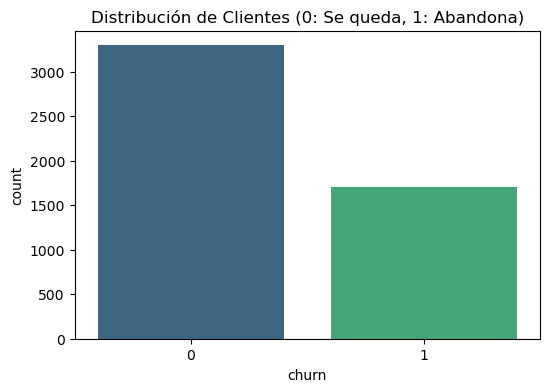

In [4]:
#1 Visualizar la distribución de Churn
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='churn', palette='viridis')
plt.title('Distribución de Clientes (0: Se queda, 1: Abandona)')
plt.show()

In [5]:
#Distribución de Clientes (Gráfico de Barras)

# Este gráfico mide el desequilibrio de clases en el dataset.

# Donde la gran mayoría de tus clientes se mantienen (0), pero tenemos una cantidad significativa de abandonos (1).

# Interpretación: Visualmente, parece que el churn representa aproximadamente un 30-35% de la base total.

# Para entrenar un modelo de Machine Learning más adelante, este "desbalance" es importante; 
# si el grupo 1 fuera mucho más pequeño, tendrías que usar técnicas especiales (como sobremuestreo) 
# para que el modelo aprenda bien a identificar a los que se van.

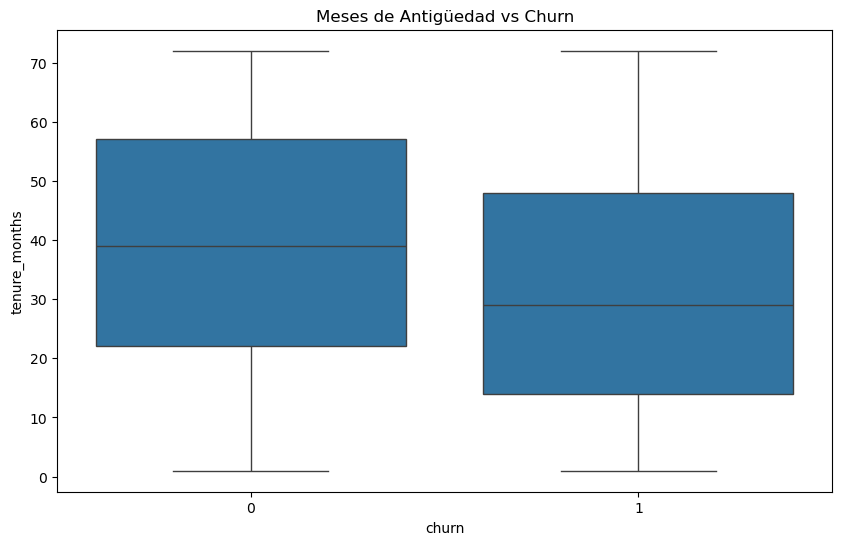

In [6]:
#2 Relación: Antigüedad vs Churn (Hipótesis: ¿los nuevos se van más?)
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='churn', y='tenure_months')
plt.title('Meses de Antigüedad vs Churn')
plt.show()

In [7]:
# Meses de Antigüedad vs. Churn (Boxplot)

#Aquí comparamos la "lealtad" en tiempo. El boxplot muestra la mediana (la línea negra central) y la dispersión del 50% de los datos (la caja azul).

# Osea los clientes que se quedan (0) tienen una mediana de antigüedad notablemente más alta (cerca de los 40 meses).
# que los que se van (1) (cuya mediana está cerca de los 30 meses).

# La hipótesis de que "los nuevos se van más" parece ser correcta. 
# La caja del grupo 1 está más abajo en el eje Y, lo que indica que el riesgo de abandono es mayor durante los primeros dos años y medio de contrato.

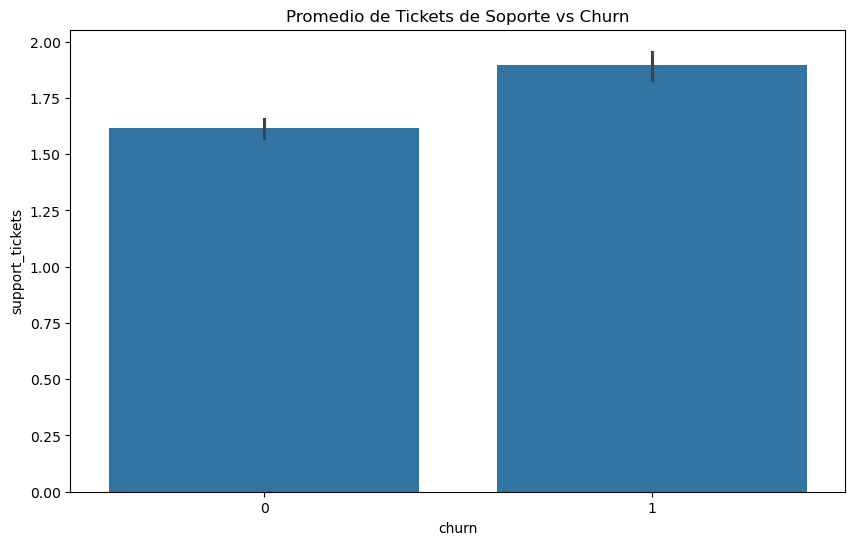

In [8]:
#3 Relación: Tickets de Soporte vs Churn
plt.figure(figsize=(10,6))
sns.barplot(data=df, x='churn', y='support_tickets')
plt.title('Promedio de Tickets de Soporte vs Churn')
plt.show()

In [9]:
# Promedio de Tickets de Soporte vs. Churn (Barplot con error).

# Este gráfico muestra la relación entre la frustración técnica/administrativa y la salida del cliente.

# Existe una correlación clara. Los clientes que abandonan generan, en promedio, más tickets de soporte (cerca de 1.9) que los que se quedan (aprox. 1.6).

# La fricción en el servicio es un "trigger" (disparador) del abandono.
# Las pequeñas líneas negras arriba de las barras (barras de error) son cortas,B
# lo que significa que esta diferencia es estadísticamente significativa y no es fruto del azar.

In [10]:
# Estrategia:

# Tenemos un problema de retención concentrado en los clientes más nuevos (menos de 30 meses). 
# y aquellos que experimentan problemas técnicos recurrentes (reflejado en el mayor volumen de tickets). 
# Para bajar el churn, deberíamos enfocarnos en mejorar la experiencia de soporte.
# Y crear planes de fidelización para los clientes que llevan menos de dos años con nosotros. 

In [11]:
# Codificación de variables y separación de conjuntos

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

#1 Copia de seguridad del dataframe
df_ml = df.copy()

#2 Codificación de variables categóricas
# Identificamos las columnas que no son números
categorical_cols = df_ml.select_dtypes(include=['object']).columns

le = LabelEncoder()
for col in categorical_cols:
    df_ml[col] = le.fit_transform(df_ml[col])

#3 Separar X (características) de y (objetivo)
X = df_ml.drop('churn', axis=1)
y = df_ml['churn']

#4 División en Entrenamiento (80%) y Prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Set de entrenamiento: {X_train.shape}")
print(f"Set de prueba: {X_test.shape}")

Set de entrenamiento: (4000, 15)
Set de prueba: (1000, 15)


In [ ]:
# Entrenamiento y Evaluación con MLflow

import mlflow
import mlflow.sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

#1 Iniciar experimento en MLflow
mlflow.set_experiment("AndesLink_Churn_Prediction")

with mlflow.start_run():
    #2 Definir y entrenar el modelo
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    
    #3 Predicciones
    y_pred = model.predict(X_test)
    auc_score = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    
    #4 Registrar parámetros y métricas en MLflow
    mlflow.log_param("n_estimators", 100)
    mlflow.log_metric("auc_roc", auc_score)
    
    #5 Guardar el modelo en MLflow
    mlflow.sklearn.log_model(model, "random_forest_model")
    
    print("Métricas del Modelo:")
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC Score: {auc_score:.4f}")

In [ ]:
# Serialización Local (El Artefacto Final)

import joblib
import os

#1 Crear carpeta models si no existe
os.makedirs('../models', exist_ok=True)

#2 Guardar el modelo serializado
model_path = '../models/modelo_churn_v1.pkl'
joblib.dump(model, model_path)

print(f"Modelo guardado exitosamente en: {model_path}")

In [ ]:
# Inicializar DVC para versionar el archivo churn_sintetico.csv.
# README: Crear el archivo README.md explicando cómo instalar el entorno de Conda y ejecutar estos scripts.
# Informe: Redactar el "Informe técnico corto" con las métricas obtenidas.